### Name: Se Rang Seo (Simon)
### Assignment 13: Probability vs Weighted Mean
### Professor: Dr. Romanowsky
### Course: Phys255 Machine Learning 2026

# Imports

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read Data

In [73]:
df = pd.read_csv('MBH_data.txt', skiprows=3, sep=r'\s+', names=['mass', 'uncertainty'])

"df";

# Put Features into Variables

In [74]:
masses = df['mass'].values
uncertainties = df['uncertainty'].values

# Histogram

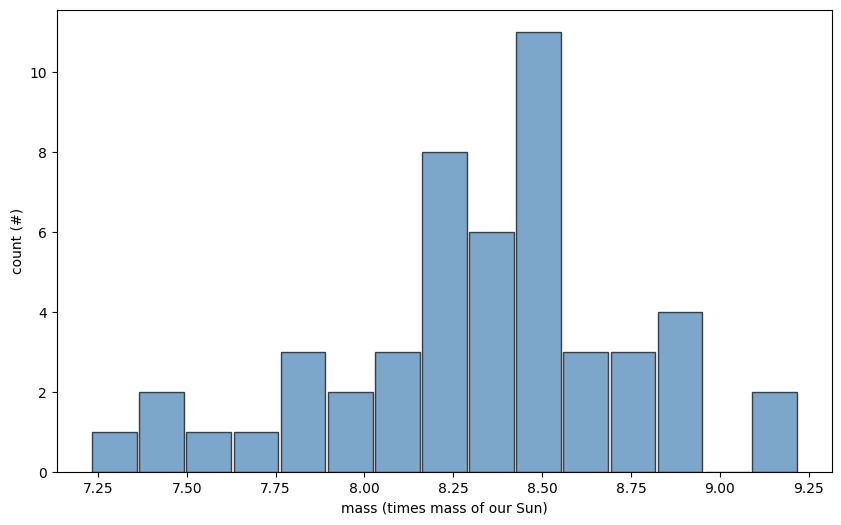

In [75]:
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(masses, bins=15, edgecolor='black', alpha=0.7, color='steelblue', rwidth=0.95)
plt.xlabel("mass (times mass of our Sun)")
plt.ylabel("count (#)");

# Define Log Equation

$ln(L)=-\frac{1}{2}\Sigma_{i=1}^N \frac{(x_i-\mu)^2}{\sigma_i^2}-\frac{1}{2}\Sigma_{i=1}^N ln(2\pi \sigma_i^2)$

Maximizing this to maximize likelihood.

In [76]:
def log_likelihood(M):
    return -0.5 * np.sum(((masses - M) / uncertainties)**2) - 0.5 * np.sum(np.log(2 * np.pi * uncertainties**2))

# Calculate range of masses

In [77]:
M_values = np.linspace(1, 10, 1000)
logL_values = [log_likelihood(M) for M in M_values]

# Find the best mass (maximum likelihood log)

In [78]:
best_idx = np.argmax(logL_values)
M_best = M_values[best_idx]
max_logL = logL_values[best_idx]

# 1 $\sigma$ uncertanty

In [79]:
threshold = max_logL - 0.5
crossings = np.where(np.diff(np.array(logL_values) >= threshold))[0]
if len(crossings) >= 2:
    M_low = M_values[crossings[0]]
    M_high = M_values[crossings[1]]
    M_uncertainty = (M_high - M_low) / 2

print(f"\nBest mass: {M_best:.4f} +/- {M_uncertainty:.4f} M_sun")


Best mass: 8.3784 +/- 0.0495 M_sun


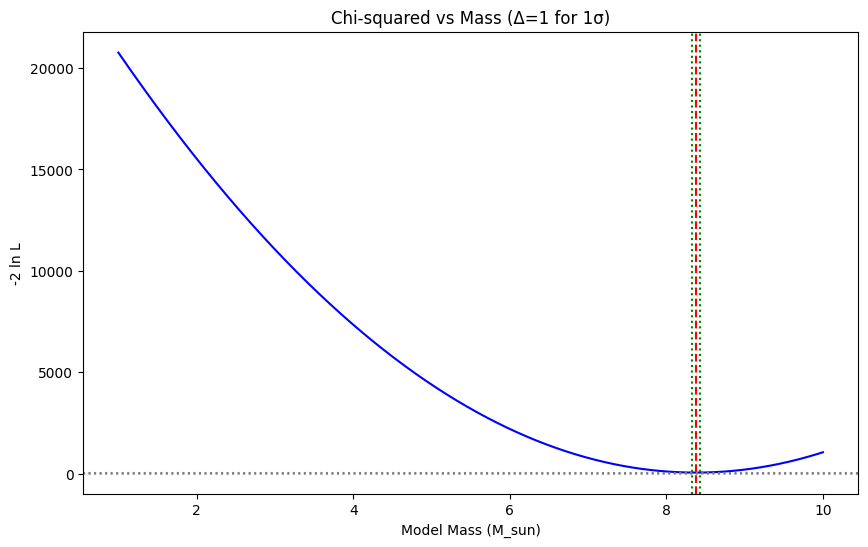

In [80]:
plt.figure(figsize=(10, 6))
neg2logL = [-2 * L for L in logL_values]
plt.plot(M_values, neg2logL, 'b-')
plt.axvline(x=M_best, color='r', linestyle='--')
plt.axhline(y=min(neg2logL) + 1, color='gray', linestyle=':')
plt.xlabel('Model Mass (M_sun)')
plt.ylabel('-2 ln L')
plt.title('Chi-squared vs Mass (Δ=1 for 1σ)')

if len(crossings) >= 2:
    plt.axvline(x=M_low, color='g', linestyle=':', label=f'1σ bounds: {M_low:.3f}, {M_high:.3f}')
    plt.axvline(x=M_high, color='g', linestyle=':')
    plt.axhline(y=threshold, color='gray', linestyle=':', alpha=0.7)

plt.show()

# Compare with weighted mean

When measurements have different uncertainties, we give more weight to more precise measurements (smaller error bars).

### Calculate weight
1. $w_i = \frac{1}{\sigma_i^2}$, $\sigma^2 = variance$ (This scales the likelihood, not the standard deviation, $\sigma$)

### Calculate weighted mean
2. $\bar x_w = \frac{\Sigma w_i x_i}{\Sigma w_i}$

### Calculate weighted uncertainty
3. $\sigma_{\bar x} = \frac{1}{\sqrt{\Sigma w_i}}$

In [ ]:
#1
weights = 1/uncertainties**2

#2
weighted_mean = np.sum(weights * masses) / np.sum(weights)

#3
weighted_uncertainty = 1 / np.sqrt(np.sum(weights))

print(f"\nWeighted mean: {weighted_mean:.4f} +/- {weighted_uncertainty:.4f} M_sun")
print(f"MLE result:    {M_best:.4f} +/- {M_uncertainty:.4f} M_sun")


Weighted mean: 8.3774 +/- 0.0513 M_sun
MLE result:    8.3784 +/- 0.0495 M_sun


# Result

 Maximum Likelihood Estimation (MLE) is very similar to Weighted Mean.